# 2. 概述、线性代数和 NDArray
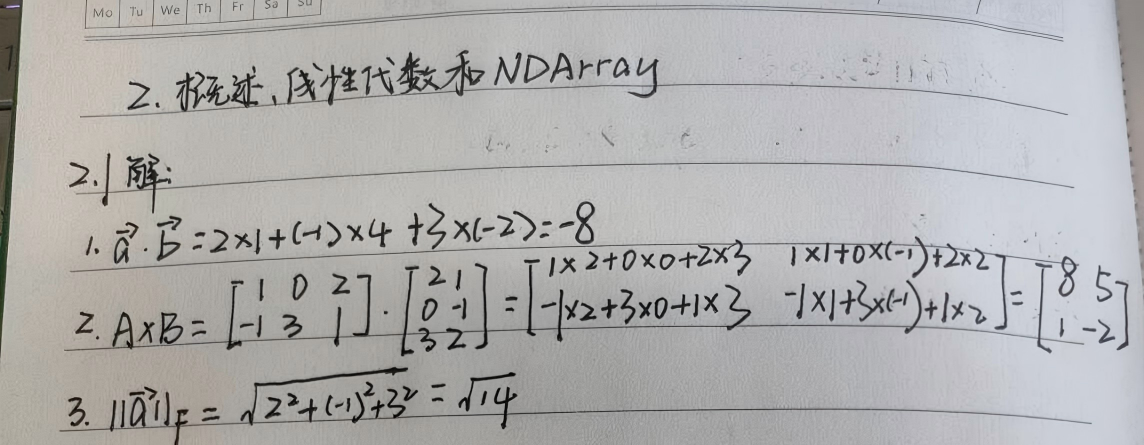

2.2 <br>
函数	分布	范围<br>
np.random.rand(3,4)	均匀分布	[0, 1)<br>
np.random.randn(3,4)	标准正态分布	无界（通常 -3~3 之间）<br>
np.random.uniform(low, high, size)	均匀分布	[low, high)<br>
np.random.normal(mean, std, size)	任意正态分布	无界

In [6]:
#2.2概述、线性代数和 NDArray
import numpy as np
#1.创建一个形状为 3 × 4 的随机矩阵 X，元素服从标准正态分布
X=np.random.randn(3,4)
print(X)

#2. 创建一个形状为 4 × 2 的全 1 矩阵 Y
Y=np.ones((4,2))
print(Y)

#3. 计算矩阵乘法 Z = X × Y
Z=np.dot(X,Y)
print(Z)

#4. 输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第 2 行所有元素。
print(Z[0,1])
print(Z[1,:])

#5. 计算 Z 的 Frobenius 范数。
print(np.linalg.norm(Z,'fro'))


[[ 1.39935544  0.92463368  0.05963037 -0.64693678]
 [ 0.69822331  0.39348539  0.89519322  0.6351718 ]
 [ 1.04955272 -0.53523521  1.31739407  0.1975996 ]]
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
[[1.73668271 1.73668271]
 [2.62207372 2.62207372]
 [2.02931117 2.02931117]]
1.7366827117133714
[2.62207372 2.62207372]
5.2932865555256114


# 3. 概率与统计
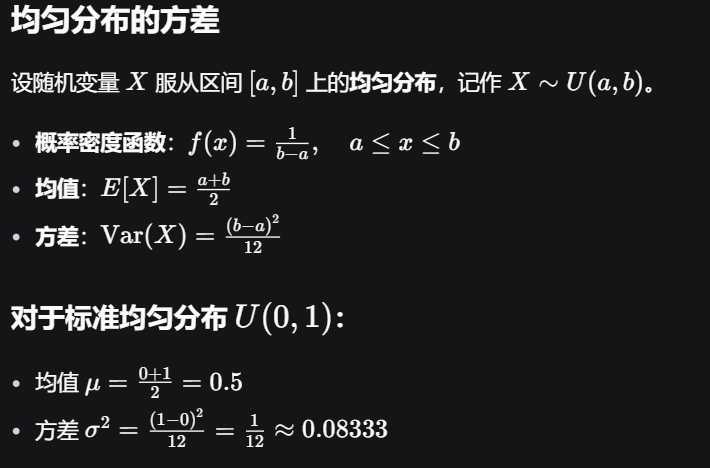
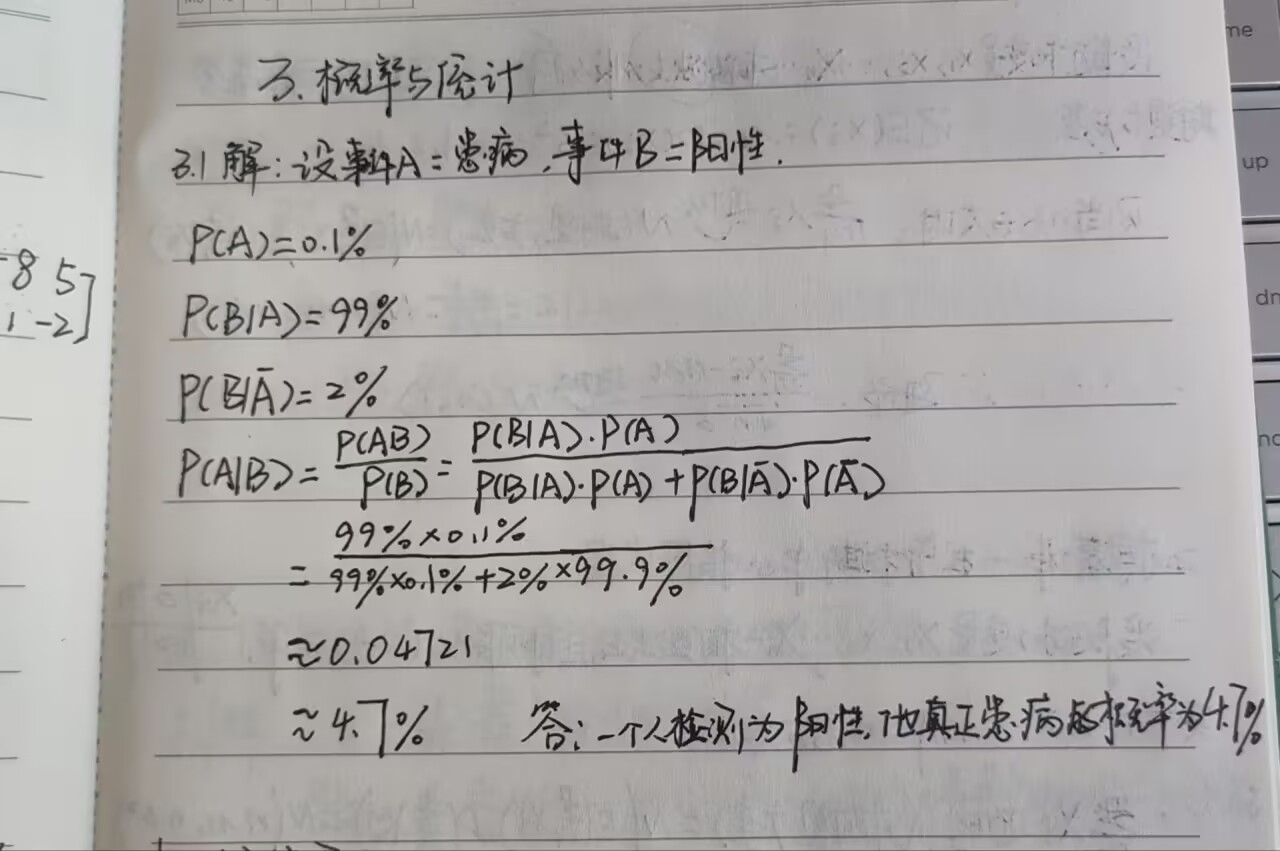
函数	分布	范围<br>
np.random.rand(3,4)	均匀分布	[0, 1)<br>
np.random.randn(3,4)	标准正态分布	无界（通常 -3~3 之间）<br>
np.random.uniform(low, high, size)	均匀分布	[low, high)<br>
np.random.normal(mean, std, size)	任意正态分布	无界

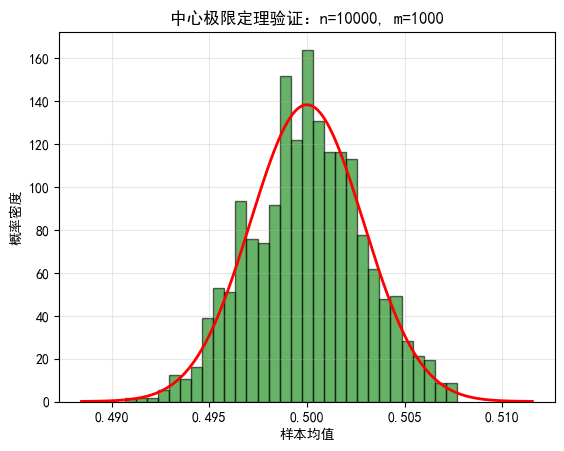

样本均值的实际方差: 0.00000845
理论方差: 0.00000833
实际方差与理论方差之比: 1.0144


In [7]:
#3.2
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
plt.rcParams['font.sans-serif'] = ['SimHei']   # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号



#1.生成 n = 10000 个服从均匀分布 U(0, 1) 的随机变量，重复 m = 1000次，每次计算这 n 个变量的均值。
n = 10000
m = 1000
samples=np.random.uniform(0,1,size=(m,n))
means=samples.mean(axis=1)
#print(means[:100])#输出前 100 个均值

#2.绘制这 1000 个均值的直方图，并叠加理论正态分布的概率密度曲线。
plt.hist(means, bins=30, density=True, alpha=0.6, color='g', edgecolor='black')
# 叠加理论正态分布的概率密度曲线
mu = 0.5  # 均值(1+0)/2=0.5
all_sigma_2 = 1/12  # 总体方差（b-a）平方和/12
sample_sigma_2 = all_sigma_2 / n  # 样本均值的方差
sigma = np.sqrt(sample_sigma_2)  # 样本均值的标准差

#x轴范围,起点终点和点数
x=np.linspace(mu-4*sigma,mu+4*sigma,1000)
#计算理论正态分布的概率密度函数
pdf=norm.pdf(x,mu,sigma)
plt.plot(x, pdf, 'r-', linewidth=2, label=f'理论正态分布 N({mu}, {sample_sigma_2:.2e})')
plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.title(f'中心极限定理验证：n={n}, m={m}')
plt.grid(alpha=0.3)
plt.show()

#3. 计算这些均值的实际方差。
true_var=np.var(means,ddof=1) #无偏样本方差
print(f"样本均值的实际方差: {true_var:.8f}")
print(f"理论方差: {sample_sigma_2:.8f}")
print(f"实际方差与理论方差之比: {true_var / sample_sigma_2:.4f}")




# 4. 导数、反向传播和复杂度
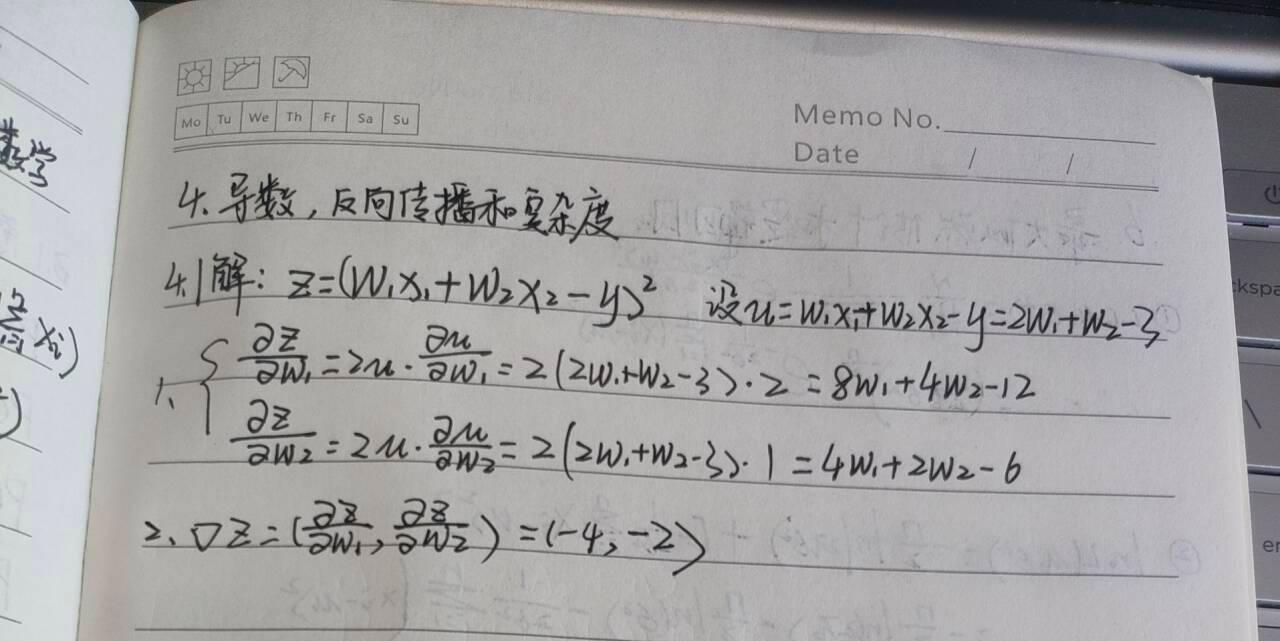

In [8]:
#4.2导数、反向传播和复杂度
import torch
#1. 定义前向计算：输入 x，经过 a = x · w1，b = a + w2，输出 L = b
#2. 给定 x = 2, w1 = 1.5, w2 = 0.5，计算前向结果。
x=torch.tensor(2.0)
w1=torch.tensor(1.5, requires_grad=True)
w2=torch.tensor(0.5, requires_grad=True)

#前向计算
a=x*w1
b=a+w2
L=b**2
print(f"前向计算结果L:{L.item()}")
print("\n")

L.backward()  # 反向传播计算梯度
print(f"torch计算的w1的梯度: {w1.grad.item()}")
print(f"torch计算的w2的梯度: {w2.grad.item()}")

#3. 手动（按链式法则）计算损失 L 对 w1, w2 的梯度，并验证与自动微分工具（如 torch.autograd）的结果是否一致。
# 手动计算梯度 a=3,  b=3.5,  L=3.5*3.5=12.25
#(dL_db)=2*b
#(db_da)=1
#(da_dw1)=x
#dL_dw1=(dL_db)*(db_da)*(da_dw1)=2*b*1*x=14
#dL_dw2=(dL_db)*(db_da)=2*b*1=7
b_val=b.item()        # 取出b的值（3.5）
x_val=x.item()        # 取出x的值（2.0）

dw1_manual=2*b_val*x_val    
dw2_manual=2*b_val            

print("\n手动计算结果：")
print("dw1=", dw1_manual)
print("dw2=", dw2_manual)

# 验证是否一致
if dw1_manual==w1.grad.item() and dw2_manual == w2.grad.item():
    print("\n验证成功：手动与自动微分结果一致！")
else:
    print("不一致。")



前向计算结果L:12.25


torch计算的w1的梯度: 14.0
torch计算的w2的梯度: 7.0

手动计算结果：
dw1= 14.0
dw2= 7.0

验证成功：手动与自动微分结果一致！


1.softmax函数接收一个向量z:1. 减去最大值；2. 取指数；3. 除以和 → 概率分布
2.交叉熵损失：衡量预测有多差,一个样本：loss = -log(p_correct);
                        多个样本：所有样本的 -log(p_correct) 求平均
3.梯度下降的参数更新公式：w1=w1-学习率*（loss对w1求偏导）
    


# 5. 线性方法、基础优化和 softmax 回归
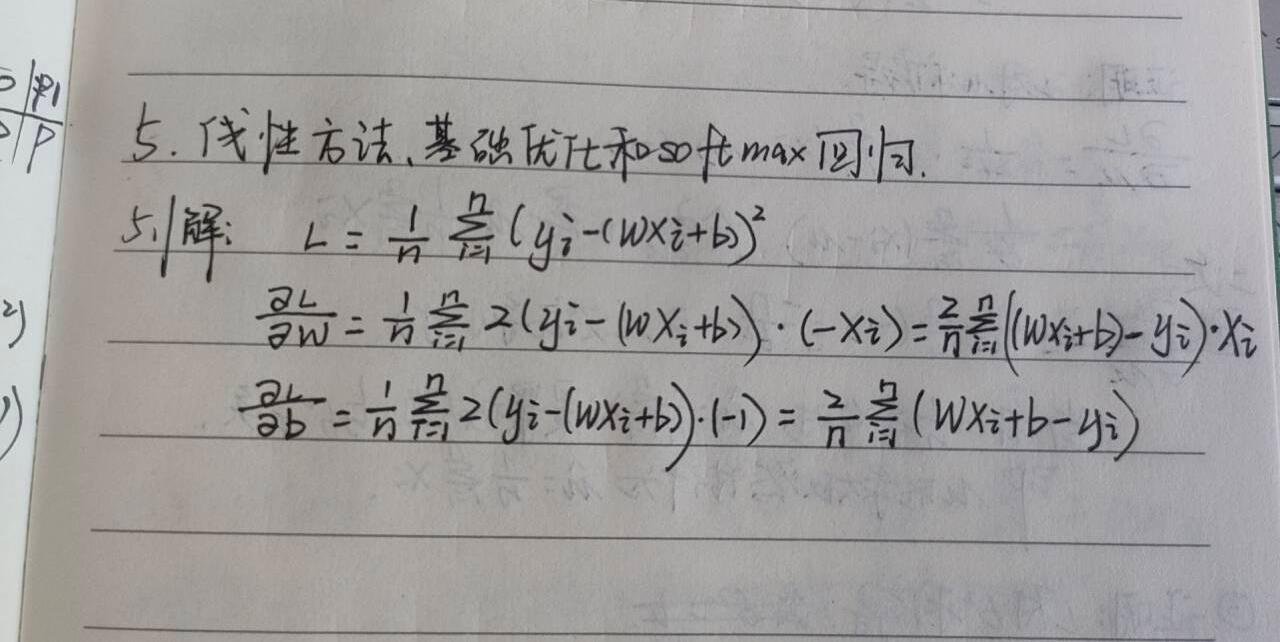


In [9]:
#5.2从零实现softmax回归对手写数字（MNIST）进行分类
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

#1. 使用 sklearn.datasets.load_digits() 。
digits = load_digits() #一共1797个样本，每个样本是一个8x8的图像，标签是0-9的数字
x= digits.data         #图片
y= digits.target       #对应的数据1-9

#2. 将数据集划分为训练集和测试集（80% 训练，20% 测试）。
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

#3. 标准化（每个特征均值为0，标准差为1）
scaler = StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

#4.one-hot编码
def one_hot(y,num_classes=10):
    n=len(y)#有多少个样本
    one_hot_y=np.zeros((n,num_classes))#创建的矩阵为全零，行：样本数，列类别数
    one_hot_y[np.arange(n),y]=1 #每行对应的类别位置置1
    return one_hot_y

y_train_onehot=one_hot(y_train)
y_test_onehot=one_hot(y_test)

# 5. 实现 softmax 函数、交叉熵损失函数。
 #(1)softmax:1. 减去最大值；2. 取指数；3. 除以和 → 概率分布
def softmax(z):
    # z: (n_samples, n_classes)
    # 减去每行最大值防止溢出
    z_shifted=z-np.max(z,axis=1,keepdims=True)
    exp_z=np.exp(z_shifted)
    return exp_z/np.sum(exp_z,axis=1,keepdims=True)
  #(2)交叉熵损失：多个样本：所有样本的 -log(p_correct) 求平均
def cross_loss(y_pred,y_true):
    # # y_pred: 概率 (n, c), y_true: one-hot (n, c)
    eps=1e-12
    y_pred=np.clip(y_pred,eps,1-eps)#防止log(0)导致的数值不稳定
    return -np.mean(np.sum(y_true*np.log(y_pred),axis=1))
  #(3)softmax回归模型：输入 x，参数 W, b，输出概率分布 p = softmax(xW + b)，损失 L = cross_loss(p, y_true)
class SoftmaxBack:
    #self：代表即将被创建的实例对象本身,input_dim：输入特征的个数（这里图片展平后是 64）。num_classes：类别个数（这里是 10，数字 0~9）。学习率和批量大小是训练过程中使用的超参数，控制模型更新的步长和每次训练使用的样本数量。
    def __init__(self,input_dim,num_classes,lr=0.1,batch_size=32):
        self.W=np.random.randn(input_dim,num_classes)*0.01
        self.b=np.zeros((1,num_classes))
        self.lr=lr
        self.batch_size=batch_size
    
    #前向计算：输入 X，计算得分 scores = XW + b，然后通过 softmax 转换为概率分布。
    def forward(self,X):
        scores=X@self.W+self.b
        return softmax(scores)
    #计算梯度：输入一个小批量的训练样本 X_batch 和对应的 one-hot 编码标签 y_batch_onehot，计算损失函数 L 对参数 W 和 b 的梯度。
    def compute_gradients(self,X_batch,y_batch_onehot):
        probs=self.forward(X_batch)                     
        dscores=probs-y_batch_onehot                  
        dW=(X_batch.T@dscores)/X_batch.shape[0]
        db=np.mean(dscores,axis=0,keepdims=True)
        return dW,db
    #训练一个 epoch：输入整个训练集 X 和对应的 one-hot 编码标签 y_onehot，打乱数据顺序，分成小批量，计算每个批量的梯度，并更新参数 W 和 b。
    def train_epoch(self,X,y_onehot):
        n=X.shape[0]
        indices=np.random.permutation(n)
        X_shuffled=X[indices]
        y_shuffled=y_onehot[indices]
        for i in range(0,n,self.batch_size):
            X_batch=X_shuffled[i:i+self.batch_size]
            y_batch=y_shuffled[i:i+self.batch_size]
            dW,db=self.compute_gradients(X_batch,y_batch)
            self.W-=self.lr*dW
            self.b-=self.lr*db
    def predict(self,X):
        probs=self.forward(X)
        return np.argmax(probs,axis=1)
    def score(self,X,y):
        y_pred=self.predict(X)
        return np.mean(y_pred==y)

# 6. 训练模型
model = SoftmaxBack(input_dim=64, num_classes=10, lr=0.1, batch_size=32)
n_epochs = 50

for epoch in range(n_epochs):
    model.train_epoch(x_train, y_train_onehot)
    if (epoch + 1) % 10 == 0:
        train_acc = model.score(x_train, y_train)
        test_acc = model.score(x_test, y_test)
        print(f"Epoch {epoch+1:3d} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

# 9. 最终测试准确率
final_acc = model.score(x_test, y_test)
print(f"\n最终测试集准确率: {final_acc:.4f} ({final_acc*100:.2f}%)")
     
    
      


Epoch  10 | Train Acc: 0.9791 | Test Acc: 0.9639
Epoch  20 | Train Acc: 0.9882 | Test Acc: 0.9667
Epoch  30 | Train Acc: 0.9903 | Test Acc: 0.9722
Epoch  40 | Train Acc: 0.9910 | Test Acc: 0.9722
Epoch  50 | Train Acc: 0.9923 | Test Acc: 0.9750

最终测试集准确率: 0.9750 (97.50%)


1. Sigmoid 函数
它把任意实数压缩到 (0,1) 之间，公式：
sigmoid(z) = 1 / (1 + e^(-z))
当 z 很大时，sigmoid 接近 1；z 很负时，接近 0。
这样我们可以把直线得分 z = w1*x1 + w2*x2 + b 转换成概率。

2. 损失函数（二元交叉熵）
对于单个样本 (x, y_true)：

如果 y_true=1，p越接近1越好，损失 = -log(p)
如果 y_true=0，p越接近0越好，损失 = -log(1-p)
合起来：Loss = -[ y_true * log(p) + (1 - y_true) * log(1-p) ]
所有样本平均就是总损失。

1. 梯度下降
损失函数对 w1, w2, b 求导，得到梯度。然后按梯度反方向更新参数：
w1 = w1 - 学习率*(∂Loss/∂w1)
w2 = w2 - 学习率*(∂Loss/∂w2)
b  = b  - 学习率*(∂Loss/∂b)
重复多次，损失会下降。



# 6. 最大似然估计和逻辑回归
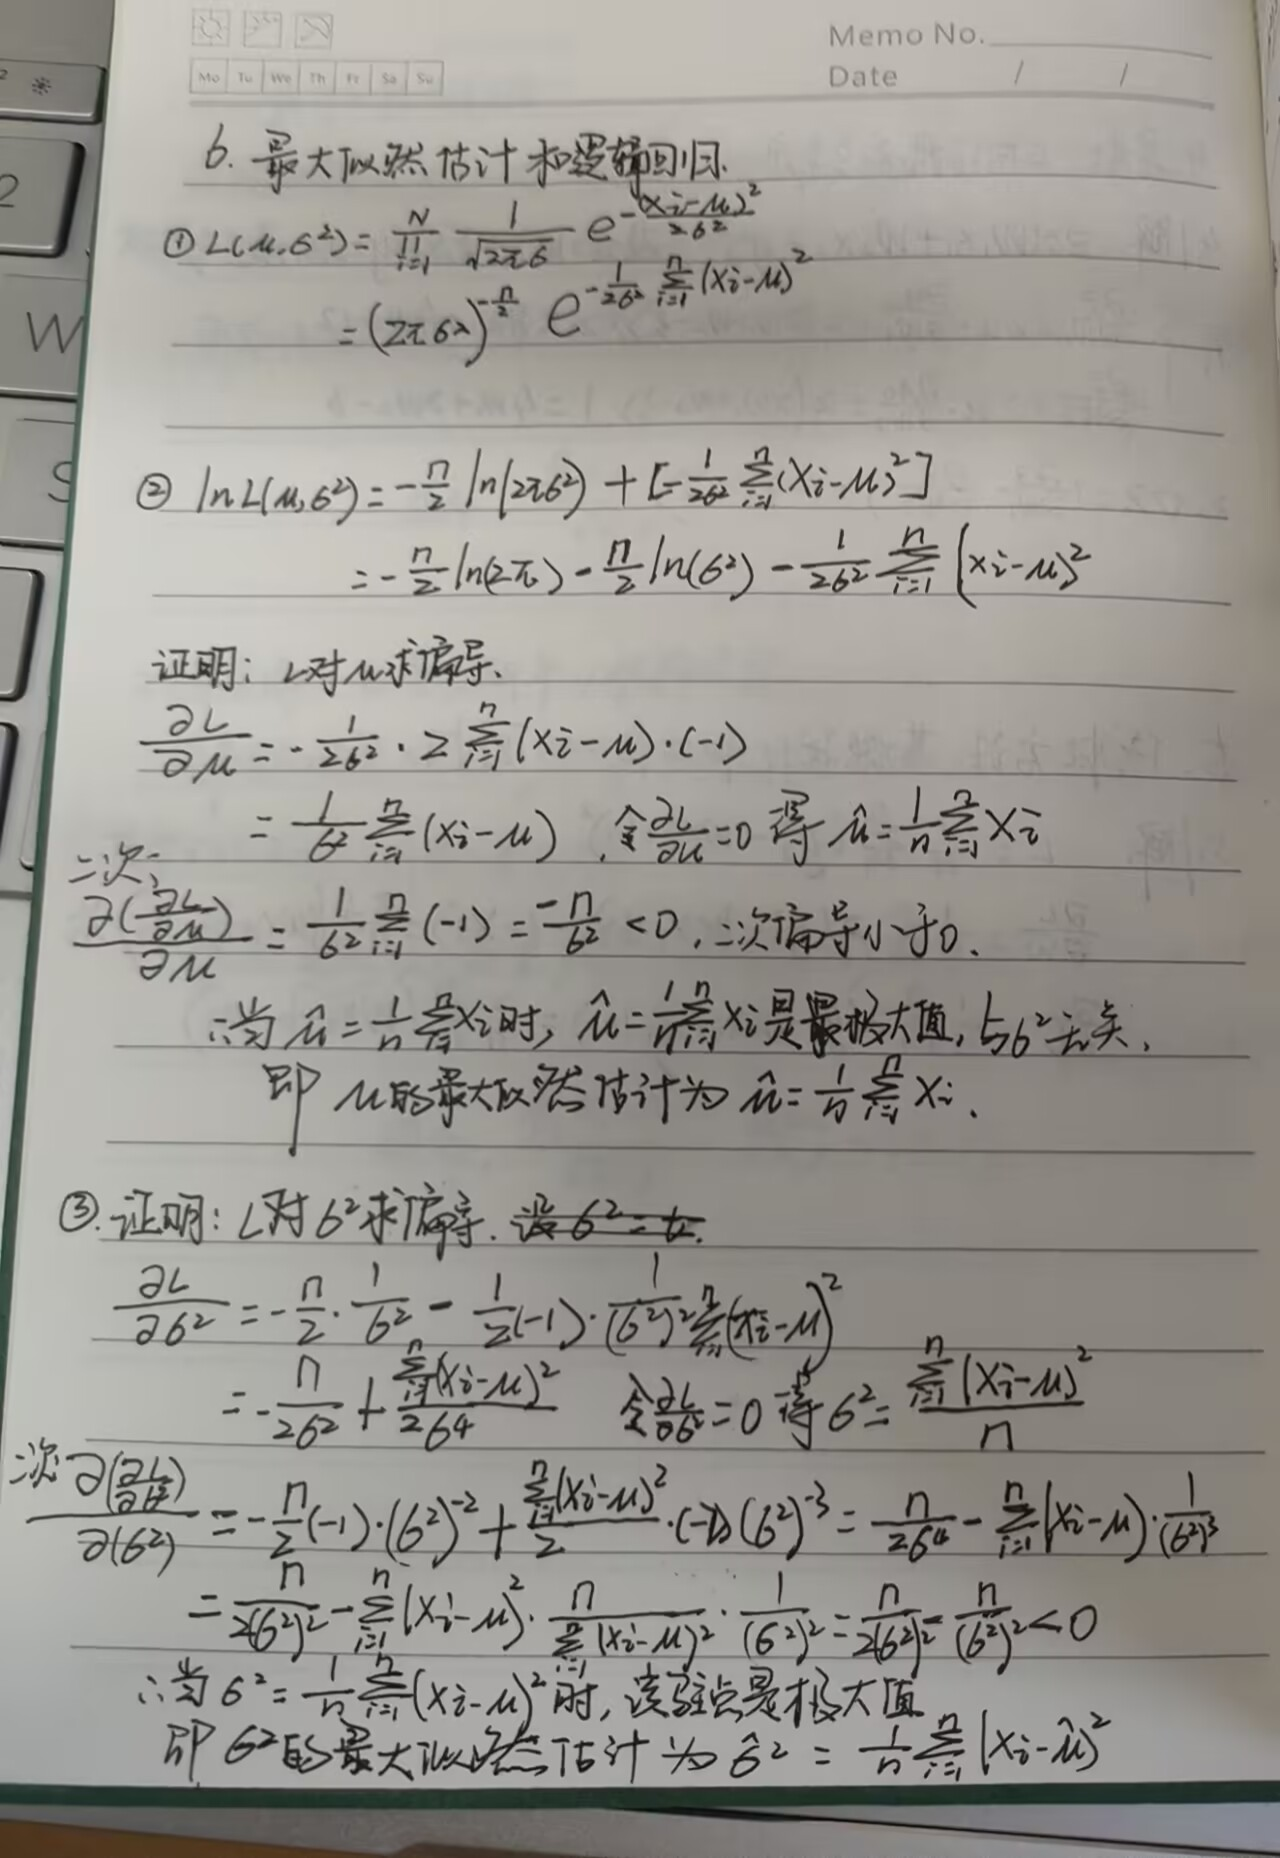

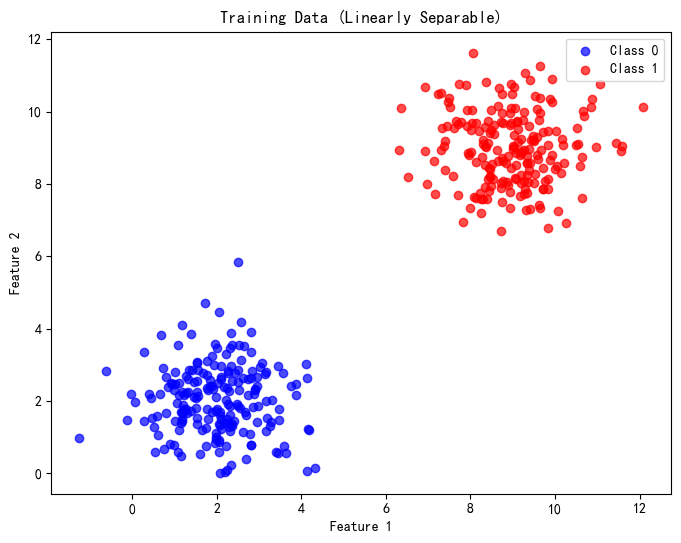

Iter 200: loss = 0.147962
Iter 400: loss = 0.080884
Iter 600: loss = 0.055549
Iter 800: loss = 0.042382
Iter 1000: loss = 0.034329


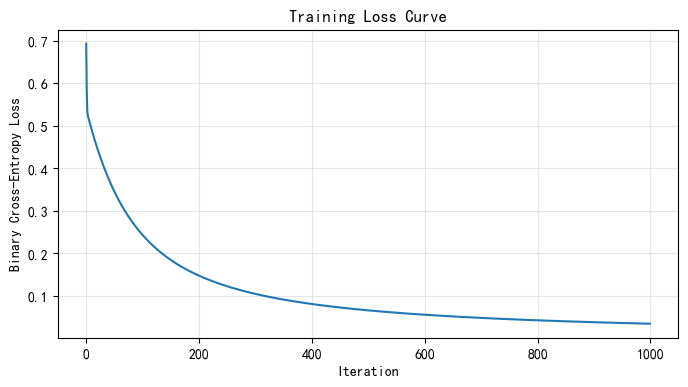

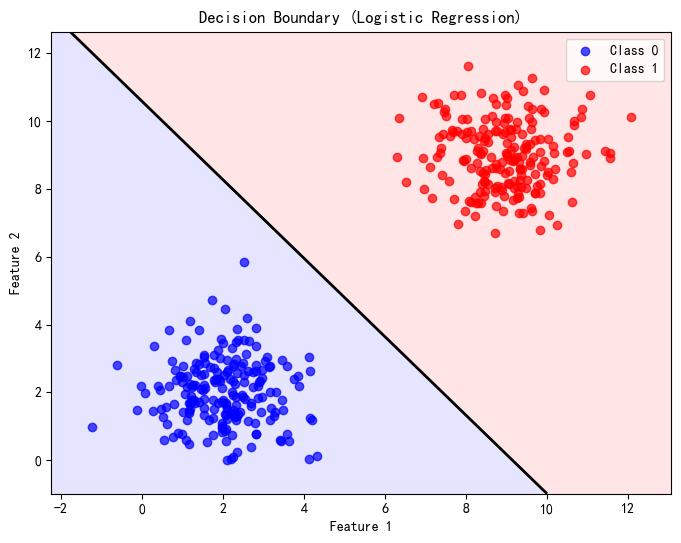

测试集准确率: 1.0000 (100.00%)


In [10]:
#6.2 最大似然估计和逻辑回归
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子，保证结果可复现
np.random.seed(42)

# 1. 生成两类线性可分的数据 
def generate_data(n_samples=200, n_features=2):
    # 类别0：均值 (2,2)，协方差为单位矩阵，特征两个分别为x和y
    mean0=np.array([2,2])#在坐标轴（2，2）附近生成数据
    cov=np.eye(n_features)
    X0=np.random.multivariate_normal(mean0, cov, n_samples)
    y0=np.zeros(n_samples)#这些点的位置是标签0
    
    # 类别1：均值 (9,9)，协方差为单位矩阵
    mean1=np.array([9,9])#在坐标轴（9，9）附近生成数据
    X1=np.random.multivariate_normal(mean1, cov, n_samples)
    y1=np.ones(n_samples)#这些点的位置是标签1
    
    # 将两类数据合并在一张表上，水平和垂直合并
    X = np.vstack((X0, X1))
    y = np.hstack((y0, y1))
    return X, y

# 生成训练集（每类200，共400）
X_train, y_train=generate_data(n_samples=200)
# 生成测试集（每类50，共100）
X_test, y_test=generate_data(n_samples=50)

# 可视化训练数据
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train==0][:, 0], X_train[y_train==0][:, 1], 
            c='blue', label='Class 0', alpha=0.7)
plt.scatter(X_train[y_train==1][:, 0], X_train[y_train==1][:, 1], 
            c='red', label='Class 1', alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Training Data (Linearly Separable)')
plt.legend()
plt.show()

# 2. 定义sigmoid函数和二元交叉熵损失 
def sigmoid(z):
    """将任意实数映射到 (0,1) 区间"""
    z = np.clip(z, -500, 500)   # 防止溢出
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_true, y_pred):
    """二元交叉熵损失，y_true: 真实标签(0/1), y_pred: 预测概率"""
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true*np.log(y_pred)+(1-y_true)*np.log(1-y_pred))

#3. 梯度下降训练逻辑回归模型 
def train_logistic_regression(X, y, lr=0.1, n_iter=1000):
    """
    X: 特征矩阵 (m, n_features)
    y: 标签向量 (m,)
    lr: 学习率
    n_iter: 迭代次数
    返回: w, b, 损失历史
    """
    m, n = X.shape
    w =np.zeros(n)      # 权重初始化为0
    b = 0.0              # 偏置初始化为0
    losses = []
    
    for i in range(n_iter):
        # 前向传播
        linear=X @ w + b
        y_pred=sigmoid(linear)
        
        # 计算损失并记录
        loss=binary_cross_entropy(y, y_pred)
        losses.append(loss)
        
        # 计算梯度
        dw = (1/m) * (X.T @ (y_pred - y))
        db = (1/m) * np.sum(y_pred - y)
        
        # 更新参数
        w=w-lr*dw
        b=b-lr*db
        
        # 每200次迭代打印损失
        if (i+1) % 200 == 0:
            print(f"Iter {i+1}: loss = {loss:.6f}")
    
    return w, b, losses

# 训练模型
w, b, losses = train_logistic_regression(X_train, y_train, lr=0.1, n_iter=1000)

# 绘制损失曲线
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Training Loss Curve')
plt.grid(alpha=0.3)
plt.show()

#  4. 绘制决策边界 
def plot_decision_boundary(X, y, w, b):
    plt.figure(figsize=(8, 6))
    plt.scatter(X[y==0][:, 0], X[y==0][:, 1], c='blue', label='Class 0', alpha=0.7)
    plt.scatter(X[y==1][:, 0], X[y==1][:, 1], c='red', label='Class 1', alpha=0.7)
    
    # 确定网格范围
    x0_min, x0_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x1_min, x1_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx0, xx1 = np.meshgrid(np.linspace(x0_min, x0_max, 200),
                           np.linspace(x1_min, x1_max, 200))
    # 计算每个网格点的预测概率
    Z = sigmoid(w[0] * xx0 + w[1] * xx1 + b)
    # 绘制等高线（决策边界为概率=0.5的线）
    plt.contour(xx0, xx1, Z, levels=[0.5], colors='black', linewidths=2)
    # 填充分类区域
    plt.contourf(xx0, xx1, Z, levels=[0, 0.5, 1], alpha=0.1, colors=['blue', 'red'])
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Decision Boundary (Logistic Regression)')
    plt.legend()
    plt.show()

plot_decision_boundary(X_train, y_train, w, b)

#  5. 计算测试集准确率 
def predict(X, w, b, threshold=0.5):
    prob = sigmoid(X @ w + b)
    return (prob >= threshold).astype(int)

y_pred = predict(X_test, w, b)
accuracy = np.mean(y_pred == y_test)
print(f"测试集准确率: {accuracy:.4f} ({accuracy*100:.2f}%)")